# Curvas de aprendizado e diagnóstico

**Tema:** Avaliação e Validação de Modelos › Viés, Variância e Curvas de Aprendizado

O notebook anterior mediu viés e variância conhecendo a função
verdadeira. Em dados reais não a conhecemos, e a pergunta continua:
**o modelo erra por viés ou por variância?** Este notebook constrói o
instrumento que responde sem conhecer $f$: a curva de aprendizado (erro
em função do tamanho do treino) e a curva de validação (erro em função
de um hiperparâmetro). Depois usa as curvas para duas decisões de
negócio: quantos dados a mais comprar e onde está o piso.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, learning_curve, validation_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(642)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR, CINZA = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100", "#5A5A5A"
print("pronto")

pronto


## 1. O que uma curva de aprendizado mostra

Treine o mesmo algoritmo com $n = 100, 200, 400, \dots$ observações e,
para cada $n$, meça o erro **no treino** e o erro **em validação**. Duas
curvas aparecem, e a decomposição do notebook anterior diz como lê-las:

| O que você vê | O que significa | O que fazer |
| :-- | :-- | :-- |
| As duas curvas convergem cedo, num erro alto | viés domina: o algoritmo não representa o fenômeno nem com muitos dados | modelo mais flexível, features novas, menos regularização |
| Erro de treino baixo, erro de validação bem acima, e o vão ainda fecha com $n$ | variância domina: o modelo é sensível à amostra | mais dados, regularização, agregação (bagging), menos features |
| Vão pequeno e curva de validação plana | você chegou perto do piso deste conjunto de features | dado novo (outra fonte), não modelo novo |
| Erro de treino sobe com $n$ | normal: com poucos pontos é fácil memorizar; com muitos, o modelo tem de generalizar | nada; é o comportamento esperado |

**Analogia.** Um estudante que tira 10 nos exercícios de casa e 5 na
prova tem um problema de variância: decorou os exercícios. Mais
exercícios (dados) e menos decoreba (regularização) ajudam. Um estudante
que tira 5 em casa e 5 na prova tem um problema de viés: não entendeu a
matéria. Mais exercícios do mesmo tipo não mudam a nota; ele precisa de
outra explicação (outro modelo, outra feature).

O erro de treino é a parte da curva que quase todo mundo ignora e que
carrega metade do diagnóstico. Sem ele, um erro de validação alto é
ambíguo: pode ser viés ou variância.

## 2. Um problema com resposta conhecida

Uma transportadora quer prever o **tempo de entrega** (em horas) a
partir de 6 features: distância, peso, densidade urbana da região, hora
de saída, se é véspera de feriado e a chuva prevista. A relação real
tem interações (chuva pesa mais em região densa) e uma não linearidade
em hora de saída. O ruído tem desvio `SIGMA`: coisas que nenhuma
feature captura (o motorista parou para almoçar, o cliente não atendeu).

Como conhecemos $\sigma$, sabemos o piso: para ruído gaussiano, o menor
MAE possível é $\sigma\sqrt{2/\pi} \approx 0{,}80\,\sigma$.

In [2]:
SIGMA = 1.2                         # horas de ruído irredutível
N_TOTAL = 12000
TAMANHOS = [100, 200, 400, 800, 1600, 3200, 6400, 9600]

def gera_entregas(n, semente):
    g = np.random.default_rng(semente)
    dist = g.gamma(3, 12, n)                        # km
    peso = g.gamma(2, 4, n)                         # kg
    densidade = g.random(n)                         # 0 = rural, 1 = centro
    hora = g.integers(6, 20, n)                     # hora de saída
    vespera = (g.random(n) < 0.08).astype(int)
    chuva = g.gamma(1.2, 4, n)                      # mm previstos
    tempo = (0.9 + 0.045 * dist + 0.02 * peso
             + 2.5 * densidade * (1 + 0.06 * chuva)                 # chuva pesa mais no centro
             + 1.8 * np.exp(-((hora - 17.5) / 1.6) ** 2)            # pico da tarde
             + 1.5 * vespera + 0.03 * chuva)
    X = np.column_stack([dist, peso, densidade, hora, vespera, chuva])
    return X, tempo + g.normal(0, SIGMA, n)

X, y = gera_entregas(N_TOTAL, 0)
piso_mae = SIGMA * np.sqrt(2 / np.pi)
print(f"{N_TOTAL} entregas | tempo médio {y.mean():.1f} h | piso teórico do MAE = {piso_mae:.3f} h")

12000 entregas | tempo médio 4.9 h | piso teórico do MAE = 0.957 h


## 3. A curva de aprendizado do zero

Para cada tamanho $n$: sorteia $n$ observações, faz 5-fold dentro delas,
guarda o MAE de treino e de validação. Repetimos com algumas sementes
porque, com $n$ pequeno, o sorteio de quem entra pesa muito.

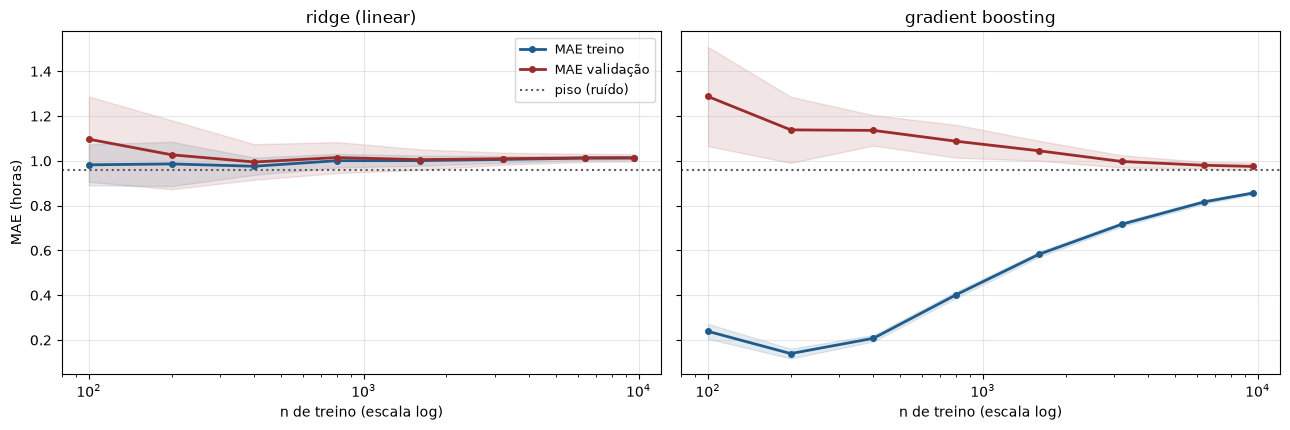

    ridge (linear): em n = 9600, treino 1.013 | validação 1.014 | piso 0.957
 gradient boosting: em n = 9600, treino 0.856 | validação 0.975 | piso 0.957


In [3]:
def curva_do_zero(fabrica, X, y, tamanhos, n_sementes=3, k=5):
    linhas = []
    for n in tamanhos:
        for s in range(n_sementes):
            idx = np.random.default_rng(s).choice(len(y), n, replace=False)
            Xn, yn = X[idx], y[idx]
            for tr, va in KFold(k, shuffle=True, random_state=s).split(Xn):
                m = fabrica().fit(Xn[tr], yn[tr])
                linhas.append({"n": n, "treino": np.abs(yn[tr] - m.predict(Xn[tr])).mean(),
                               "validação": np.abs(yn[va] - m.predict(Xn[va])).mean()})
    return pd.DataFrame(linhas).groupby("n").agg(["mean", "std"])

ridge = lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0))
gbm = lambda: HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                            min_samples_leaf=10, random_state=0)
curvas = {"ridge (linear)": curva_do_zero(ridge, X, y, TAMANHOS),
          "gradient boosting": curva_do_zero(gbm, X, y, TAMANHOS)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, (nome, c) in zip(axes, curvas.items()):
    for col, cor in [("treino", AZUL), ("validação", VERMELHO)]:
        ax.plot(c.index, c[(col, "mean")], color=cor, lw=2, marker="o", ms=4, label=f"MAE {col}")
        ax.fill_between(c.index, c[(col, "mean")] - c[(col, "std")], c[(col, "mean")] + c[(col, "std")],
                        color=cor, alpha=0.12)
    ax.axhline(piso_mae, color=CINZA, ls=":", lw=1.5, label="piso (ruído)")
    ax.set_xscale("log"); ax.set_xlabel("n de treino (escala log)"); ax.set_title(nome)
axes[0].set_ylabel("MAE (horas)"); axes[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

for nome, c in curvas.items():
    n_max = c.index.max()
    print(f"{nome:>18s}: em n = {n_max}, treino {c.loc[n_max, ('treino', 'mean')]:.3f} | "
          f"validação {c.loc[n_max, ('validação', 'mean')]:.3f} | piso {piso_mae:.3f}")

**Leitura esperada:** a ridge converge antes de $n = 800$ e para num MAE
bem acima do piso, com treino e validação coladas. Viés: uma reta não
representa o pico da tarde nem a interação chuva × densidade, e
nenhuma quantidade de dados vai ensiná-la. O boosting começa com um vão
enorme (com 100 pontos ele memoriza), mas o vão fecha conforme $n$
cresce e a curva de validação desce em direção ao piso. Variância, que
dados curam.

A decisão prática já está tomada: com esta base, trocar a ridge por
um modelo flexível vale mais que comprar dados; com o boosting, a
pergunta seguinte é "quanto mais dados compensa comprar?".

## 4. A mesma curva com o `scikit-learn`

`learning_curve` faz o laço acima com CV; `train_sizes` pode ser dado em
fração ou em contagem. Usamos `neg_mean_absolute_error` porque o
`scikit-learn` sempre maximiza.

In [4]:
tamanhos_sk, tr_sk, va_sk = learning_curve(
    gbm(), X, y, train_sizes=np.array(TAMANHOS[:-1]), cv=KFold(5, shuffle=True, random_state=0),
    scoring="neg_mean_absolute_error", shuffle=True, random_state=0)
tabela = pd.DataFrame({"n": tamanhos_sk, "MAE treino": -tr_sk.mean(axis=1),
                       "MAE validação": -va_sk.mean(axis=1), "dp validação": va_sk.std(axis=1)})
print(tabela.round(3).to_string(index=False))

   n  MAE treino  MAE validação  dp validação
 100       0.188          1.209         0.039
 200       0.127          1.177         0.014
 400       0.264          1.121         0.008
 800       0.466          1.064         0.009
1600       0.630          1.020         0.006
3200       0.758          0.999         0.007
6400       0.839          0.980         0.010


Um detalhe que muda o número: `learning_curve` usa, em cada fold, os
primeiros `train_size` índices do treino daquele fold, com a validação
sempre do tamanho cheio ($n/5$ da base inteira). Na versão do zero, a
validação encolhia junto com $n$. Para o diagnóstico tanto faz; para
comparar números entre implementações, não.

## 5. Extrapolando: quantos dados comprar?

Curvas de aprendizado costumam seguir uma lei de potência (Cortes et
al., 1994; Hestness et al., 2017):

$$\text{erro}(n) \approx a + b\,n^{-c}$$

com $a$ o **piso assintótico** deste algoritmo com estas features, e
$c$ a velocidade com que ele se aproxima do piso. Ajustar os três
parâmetros aos pontos medidos permite duas perguntas: "onde a curva vai
parar?" e "quantos pontos preciso para chegar num erro-alvo?".

O ajuste é frágil (três parâmetros, poucos pontos, muito ruído nos $n$
pequenos), então: use só a curva de **validação**, dê mais peso aos $n$
grandes e trate o resultado como ordem de grandeza.

ajuste: erro(n) = 0.902 + 1.92 · n^(-0.360)
piso estimado pela curva: 0.902 h   |   piso real (σ√(2/π)): 0.957 h
para MAE = 0.95 h, a lei de potência prevê n ≈ 27,540 entregas rotuladas
o piso real é 0.957 h: a meta de 0.95 h não existe


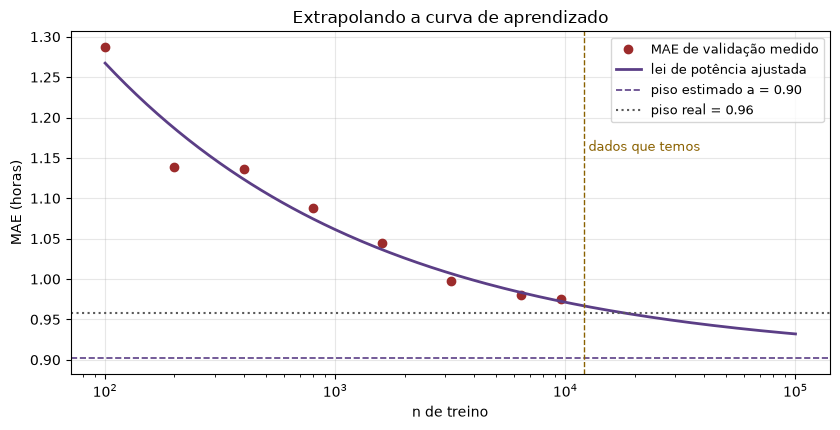

In [5]:
def lei_de_potencia(n, a, b, c):
    return a + b * n ** (-c)

c_gbm = curvas["gradient boosting"]
n_obs = c_gbm.index.to_numpy(dtype=float)
mae_obs = c_gbm[("validação", "mean")].to_numpy()
pesos = 1 / np.sqrt(n_obs)                                   # sigma ~ 1/sqrt(n): pontos grandes pesam mais
(a, b, c), _ = curve_fit(lei_de_potencia, n_obs, mae_obs, p0=[1, 5, 0.5], sigma=pesos, maxfev=20000)
print(f"ajuste: erro(n) = {a:.3f} + {b:.2f} · n^(-{c:.3f})")
print(f"piso estimado pela curva: {a:.3f} h   |   piso real (σ√(2/π)): {piso_mae:.3f} h")

ALVO = 0.95                                                  # MAE que a operação pediu, em horas
if ALVO > a:
    n_alvo = (b / (ALVO - a)) ** (1 / c)
    print(f"para MAE = {ALVO} h, a lei de potência prevê n ≈ {n_alvo:,.0f} entregas rotuladas")
else:
    print(f"MAE = {ALVO} está abaixo do piso estimado {a:.3f}: nenhuma quantidade de dados chega lá")
print(f"o piso real é {piso_mae:.3f} h: a meta de {ALVO} h {'não existe' if ALVO < piso_mae else 'é atingível'}")

grade_n = np.logspace(2, 5, 200)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(n_obs, mae_obs, "o", color=VERMELHO, label="MAE de validação medido")
ax.plot(grade_n, lei_de_potencia(grade_n, a, b, c), color=ROXO, lw=2, label="lei de potência ajustada")
ax.axhline(a, color=ROXO, ls="--", lw=1.2, label=f"piso estimado a = {a:.2f}")
ax.axhline(piso_mae, color=CINZA, ls=":", lw=1.5, label=f"piso real = {piso_mae:.2f}")
ax.axvline(N_TOTAL, color=AMBAR, lw=1, ls="--"); ax.text(N_TOTAL * 1.05, mae_obs.max() * 0.9,
                                                        "dados que temos", color=AMBAR, fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("n de treino"); ax.set_ylabel("MAE (horas)"); ax.legend(fontsize=9)
ax.set_title("Extrapolando a curva de aprendizado")
plt.tight_layout(); plt.show()

**Leitura esperada:** o ajuste acompanha bem os pontos medidos, e ainda
assim estima o piso **abaixo** do real: promete um MAE de 0,95 h com
algumas dezenas de milhares de entregas, e 0,95 h está abaixo do que o
ruído permite. Em dados reais você não teria a linha pontilhada para
denunciar o erro. É por isso que o `a` estimado precisa ser confrontado
com uma estimativa independente de $\sigma$ (seção 8 do notebook
anterior) antes de virar promessa. Mude `ALVO` para 1,00 e para 0,97 e
repare: perto do piso, o $n$ necessário explode, porque a curva é quase
plana ali. Essa é a conversa que a curva permite ter com quem paga a
rotulagem: "o próximo centésimo de hora custa 10 mil entregas; o
seguinte, 30 mil; o de depois talvez não exista".

Em produção, o custo de rotular varia de zero (o tempo de entrega é
registrado de graça pela operação) a caro (um médico laudando imagens).
Quando é caro, esta curva é o instrumento de orçamento. Quando é de
graça, a curva diz outra coisa: quanto tempo esperar antes de retreinar
com mais histórico (tema 13).

## 6. A curva de validação: erro em função do hiperparâmetro

A segunda curva fixa $n$ e varia um botão de complexidade. É a curva em
U do notebook anterior, medida sem conhecer $f$: o erro de validação faz
o U, e o erro de treino só desce. O modelo é uma árvore de decisão, que
tem o botão mais legível de todos: `max_depth`.

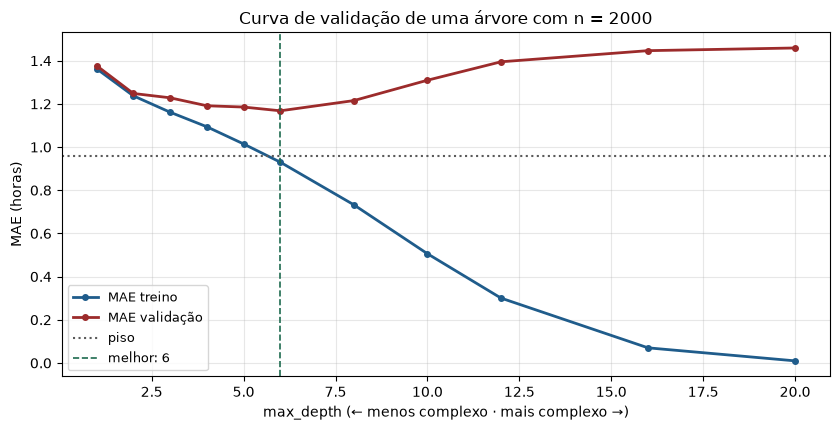

 max_depth  treino  validação   vão
         1   1.363      1.377 0.014
         2   1.237      1.248 0.011
         3   1.162      1.228 0.067
         4   1.094      1.191 0.097
         5   1.014      1.185 0.171
         6   0.930      1.168 0.238
         8   0.732      1.215 0.483
        10   0.506      1.310 0.804
        12   0.301      1.395 1.094
        16   0.070      1.447 1.376
        20   0.010      1.459 1.449


In [6]:
N_CURVA = 2000
profundidades = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20]
idx = rng.choice(N_TOTAL, N_CURVA, replace=False)
tr_v, va_v = validation_curve(
    DecisionTreeRegressor(random_state=0), X[idx], y[idx], param_name="max_depth",
    param_range=profundidades, cv=KFold(5, shuffle=True, random_state=0),
    scoring="neg_mean_absolute_error")
mae_tr, mae_va = -tr_v.mean(axis=1), -va_v.mean(axis=1)
melhor = profundidades[int(np.argmin(mae_va))]

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(profundidades, mae_tr, color=AZUL, lw=2, marker="o", ms=4, label="MAE treino")
ax.plot(profundidades, mae_va, color=VERMELHO, lw=2, marker="o", ms=4, label="MAE validação")
ax.axhline(piso_mae, color=CINZA, ls=":", lw=1.5, label="piso")
ax.axvline(melhor, color=VERDE, ls="--", lw=1.2, label=f"melhor: {melhor}")
ax.set_xlabel("max_depth (← menos complexo · mais complexo →)")
ax.set_ylabel("MAE (horas)"); ax.legend(fontsize=9)
ax.set_title(f"Curva de validação de uma árvore com n = {N_CURVA}")
plt.tight_layout(); plt.show()
print(pd.DataFrame({"max_depth": profundidades, "treino": mae_tr.round(3), "validação": mae_va.round(3),
                    "vão": (mae_va - mae_tr).round(3)}).to_string(index=False))

À esquerda, as duas curvas juntas e altas: viés (uma árvore de
profundidade 1 é um único degrau). À direita, treino caindo a zero e
validação subindo: variância (com profundidade 20 a árvore tem uma folha
por entrega e memoriza o ruído). O vão entre as curvas é a coluna `vão`:
ele mede a variância diretamente, e é o que a poda e a regularização
compram.

**Troque `N_CURVA` por 8000** e rode de novo. O mínimo se move para a
direita (árvores mais profundas passam a compensar) e o vão encolhe em
todo o eixo. É a mesma lição do notebook anterior, agora sem conhecer $f$:
a complexidade certa depende de $n$.

## 7. Um protocolo de diagnóstico

Junte as duas curvas e o diagnóstico vira uma sequência de perguntas:

1. **Erro de treino já está alto?** Viés. Não adianta mexer em dados;
   mexa em capacidade (modelo, features, interações, menos
   regularização). Confirme com a curva de validação: se o melhor ponto
   está no extremo "mais complexo" do intervalo testado, o intervalo
   estava curto.
2. **Erro de treino baixo e vão grande?** Variância. A curva de
   aprendizado diz se dados curam (curva de validação ainda descendo) ou
   se é hora de regularizar (curva plana com vão). A curva de validação
   diz quanto regularizar.
3. **Vão pequeno e validação plana, acima da meta?** Piso do conjunto de
   features. Estime $\sigma$ (observações repetidas, concordância entre
   rotuladores) e leve para a conversa: a meta precisa de informação
   nova.
4. **Tudo bem em validação e ruim em produção?** Não é viés nem
   variância; é a validação que não imitou a produção (módulo 3).

Um erro comum é rodar as curvas com uma única semente e um $n$ pequeno,
ler ruído como tendência, e concluir que "dados não ajudam". Repita com
sementes e olhe a banda, como na seção 3.

## O que levar deste notebook

- A curva de aprendizado mostra viés (curvas convergem alto) e
  variância (vão) sem conhecer a função verdadeira. O erro de treino é
  metade do diagnóstico.
- A lei de potência $a + b\,n^{-c}$ extrapola a curva: estima o piso e o
  $n$ necessário para uma meta. Trate como ordem de grandeza.
- A curva de validação é a curva em U medida na prática; o vão entre
  treino e validação é a variância.
- Diagnóstico antes de remédio: mais dados só curam variância;
  capacidade só cura viés; nada cura o ruído.

→ Próximo módulo: **Calibração de Probabilidades**, onde a pergunta deixa
de ser "quanto o modelo erra" e passa a ser "dá para acreditar no 0,8
que ele devolve?".